# 1 Data exploring and preprocessing

In [13]:
"""
Data Exploration: Mobile Device Usage and User Behavior

Dataset:
Khorasani, V. (2024). Mobile Device Usage and User Behavior Dataset. 
Kaggle. https://doi.org/10.34740/KAGGLE/DV/4455

License: Apache 2.0
"""

'\nData Exploration: Mobile Device Usage and User Behavior\n\nDataset:\nKhorasani, V. (2024). Mobile Device Usage and User Behavior Dataset. \nKaggle. https://doi.org/10.34740/KAGGLE/DV/4455\n\nLicense: Apache 2.0\n'

In [14]:
### import libraries 

import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### set working directory
os.chdir(r'C:\Users\heike\Documents\decoding-device-behavior')


### helper function to load data from a CSV file into a pandas DataFrame

def load_data(file_path):
    """
    Load data from a CSV file into a pandas DataFrame.

    Parameters:
    file_path (str): The path to the CSV file.

    Returns:
    pd.DataFrame: A DataFrame containing the loaded data.
    """
    try:
        data = pd.read_csv(file_path)
        return data
    except FileNotFoundError:
        print(f"Error: The file at {file_path} was not found.")
        return None
    except pd.errors.EmptyDataError:
        print("Error: The file is empty.")
        return None
    except pd.errors.ParserError:
        print("Error: There was a parsing error while reading the file.")
        return None


In [15]:
# load the dataset

df=load_data('01_data/01_user_behavior_dataset_original.csv')
df

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3
...,...,...,...,...,...,...,...,...,...,...,...
695,696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4
697,698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2
698,699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1


### Data Audit

In [16]:
print(df.shape)
df.describe()

(700, 11)


,User ID,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,User Behavior Class
count,700.00000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,350.50000,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,2.990000
std,202.21688,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,1.401476
min,1.00000,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,1.000000
25%,175.75000,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,2.000000
50%,350.50000,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,3.000000
75%,525.25000,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,4.000000
max,700.00000,598.000000,12.000000,2993.000000,99.000000,2497.000000,59.000000,5.000000


In [17]:
df.isna().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
dtype: int64

### Data cleaning

In [18]:
# Cleaning the data
df['Age'] = df['Age'].astype(int) 


### Data preprocessing

In [19]:
# Additional columns for Power BI

# usage Intensity Classification based on App Usage Time (min/day)
df['Usage Intensity'] = pd.cut(
    df['App Usage Time (min/day)'],
    bins=[0, 60, 180, 360, float('inf')],
    labels=['Low (<1h)', 'Medium (1-3h)', 'High (3-6h)', 'Extreme (6h+)']
)

# Battery Drain Categories
df['Battery Category'] = pd.cut(
    df['Battery Drain (mAh/day)'],
    bins=[0, 2000, 3500, 5000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

# App share calculation: App Usage Time (min/day) / Screen On Time (min/day)
df['Screen On Time (min/day)'] = df['Screen On Time (hours/day)'] * 60
df['App_share'] = df['App Usage Time (min/day)'] / df['Screen On Time (min/day)']


### Data exploration

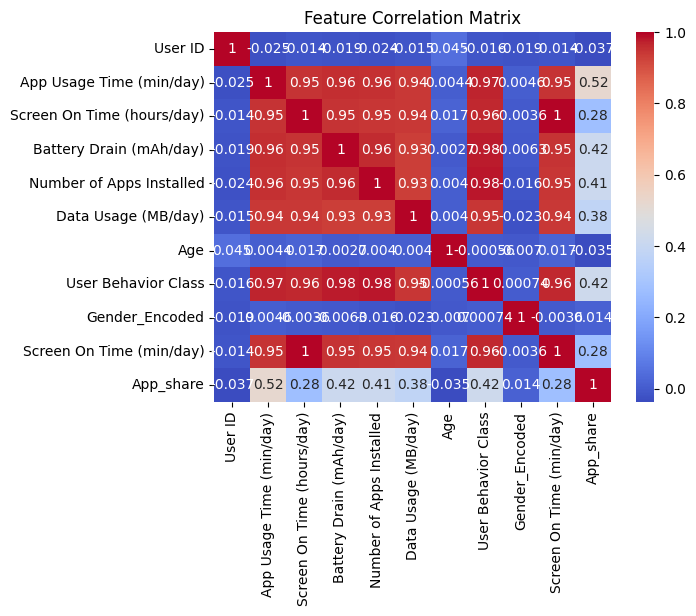

In [20]:
# Correlation matrix and heatmap

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

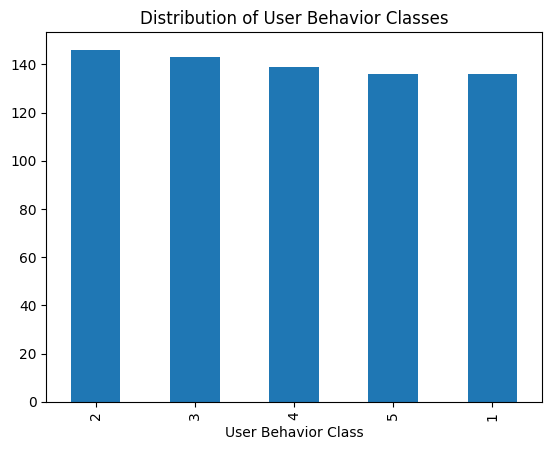

In [21]:
df['User Behavior Class'].value_counts().plot(kind='bar')
plt.title('Distribution of User Behavior Classes')
plt.show()

### Save Data

In [22]:
# Save cleaned data to a new CSV file

df.to_csv('01_data/02_user_behavior_dataset_cleaned.csv', index=False)
print("Cleaned data saved to 02_user_behavior_dataset_cleaned.csv")

Cleaned data saved to 02_user_behavior_dataset_cleaned.csv
